In [ ]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

README.md:   0%|          | 0.00/3.25k [00:00<?, ?B/s]

data_jobs.csv: reconstructing file:   0%|          |  0.00B /  231MB            

data_jobs.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

In [ ]:
! pip list

Package                               Version
------------------------------------- ------------------
absl-py                               1.4.0
accelerate                            1.14.0
access                                1.1.10.post3
affine                                3.0.1
aiofiles                              25.1.0
aiohappyeyeballs                      2.7.1
aiohttp                               3.14.3
aiosignal                             1.4.0
aiosqlite                             0.22.1
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.12.1
altair                                5.5.0
annotated-doc                         0.0.5
annotated-types                       0.8.0
antlr4-python3-runtime                4.9.3
anyio                                 4.14.2
anywidget                             0.9.21
apsw                                  3.53.4.0

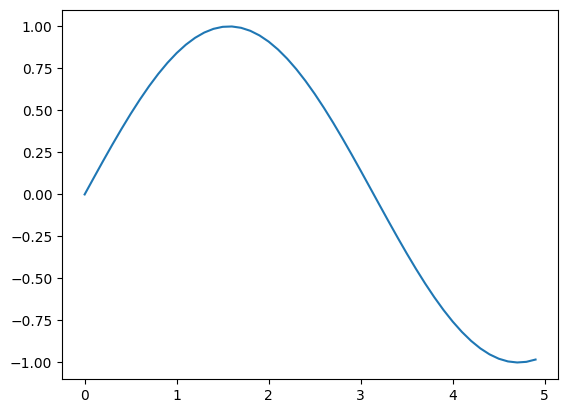

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 5, 0.1)
y = np.sin(x)
plt.plot(x, y)

## Matplotlib: Plotting

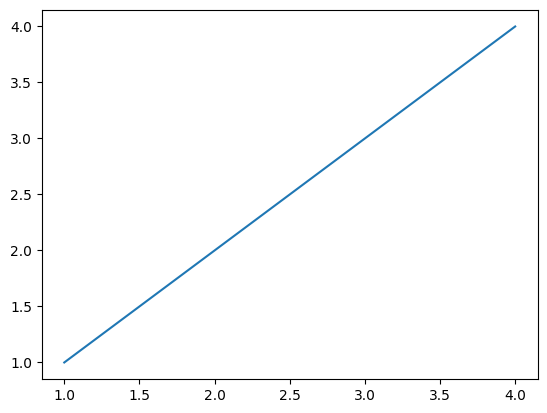

In [ ]:
# Simple Example

x = [1, 2, 3, 4]
y = [1, 2, 3, 4]

plt.plot(x, y)

In [ ]:
# To remove '[<matplotlib.lines.Line2D at 0x7ec529c307d0>]' from the output, use an addition line of code 'plt.show()'

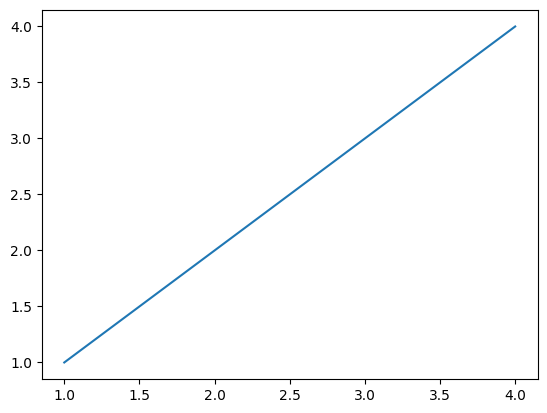

In [ ]:
x = [1, 2, 3, 4]
y = [1, 2, 3, 4]

plt.plot(x, y)
plt.show()

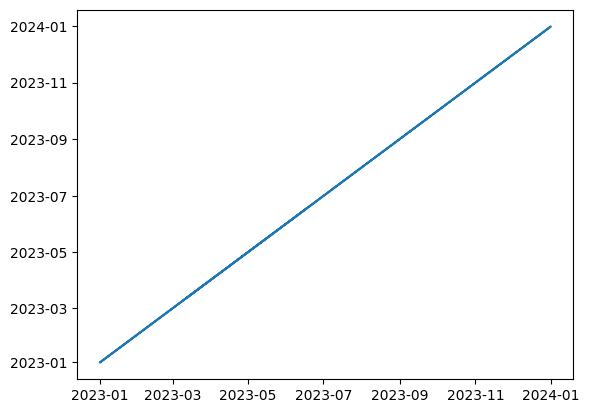

In [ ]:
# Example-1: To display the job postings over time

plt.plot(df.job_posted_date, df.job_posted_date)

In [ ]:
date_counts = df.job_posted_date.value_counts()
date_counts = date_counts.sort_index()
date_counts

,count
job_posted_date,
2023-01-01 00:00:04,1
2023-01-01 00:00:07,1
2023-01-01 00:00:22,1
2023-01-01 00:00:24,1
2023-01-01 00:00:27,1
...,...
2023-12-31 23:40:18,2
2023-12-31 23:40:22,2
2023-12-31 23:40:31,2


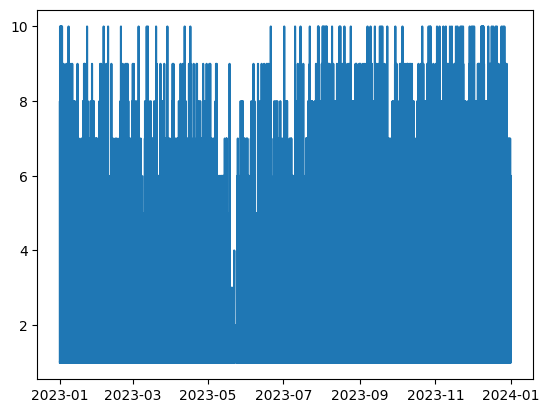

In [ ]:
plt.plot(date_counts.index, date_counts)

In [ ]:
# To remove the messy visual and aggregate it further, let's aggregate the data by month

df['job_posted_month'] = df.job_posted_date.dt.month
monthly_counts = df.job_posted_month.value_counts()
monthly_counts = monthly_counts.sort_index()

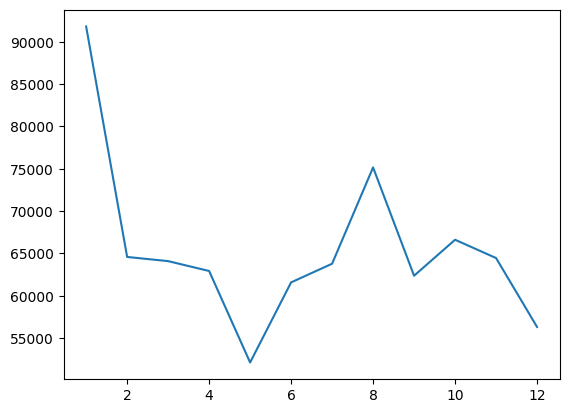

In [ ]:
plt.plot(monthly_counts.index, monthly_counts.values)

## Series vs DataFrames

- One-Dimensional
- Indexed
- Diverse Data Types


NOTE: A column of data within a dataframe is a series

In [ ]:
series = pd.Series([10, 20, 30, 40, 50], index = ['a', 'b', 'c', 'd', 'e'])

In [ ]:
print(series.index)

print(series.values)

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')
[10 20 30 40 50]


## Bar Chart: Count of Job Postings

In [ ]:
job_counts = df.job_title_short.value_counts()

<BarContainer object of 10 artists>

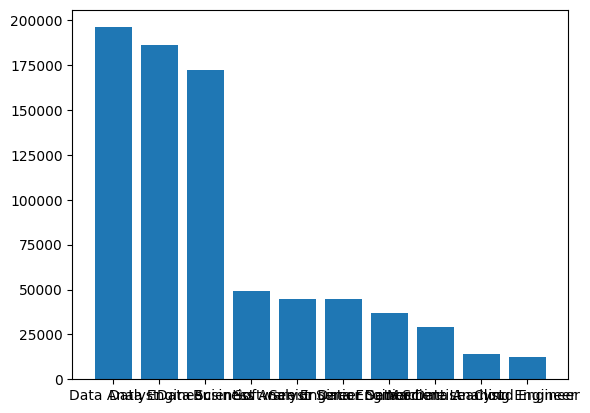

In [ ]:
plt.bar(job_counts.index, job_counts.values)

<BarContainer object of 3 artists>

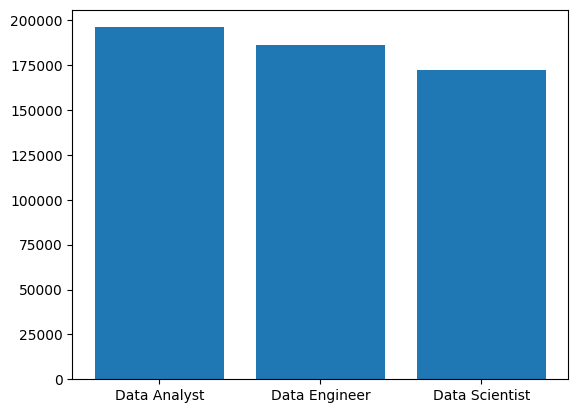

In [ ]:
job_counts_new = df['job_title_short'].value_counts().head(3)

plt.bar(job_counts_new.index, job_counts_new)

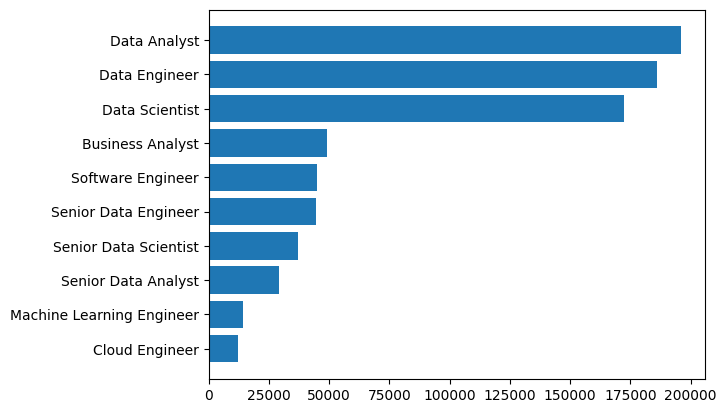

In [ ]:
job_counts = job_counts.sort_values(ascending = True)
plt.barh(job_counts.index, job_counts)
plt.show()

## Matplotlib: Labelling

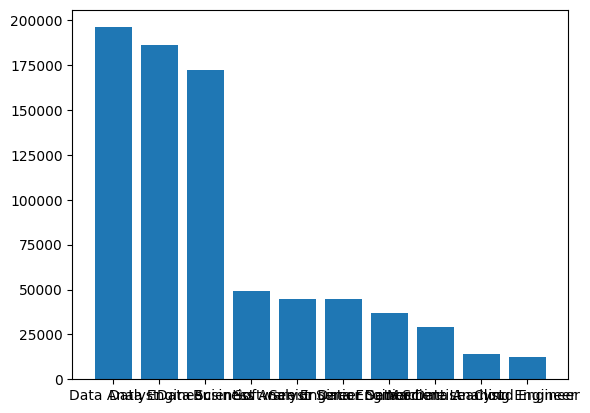

In [ ]:
job_counts = job_counts.sort_values(ascending = False)

plt.bar(job_counts.index, job_counts)

plt.show()

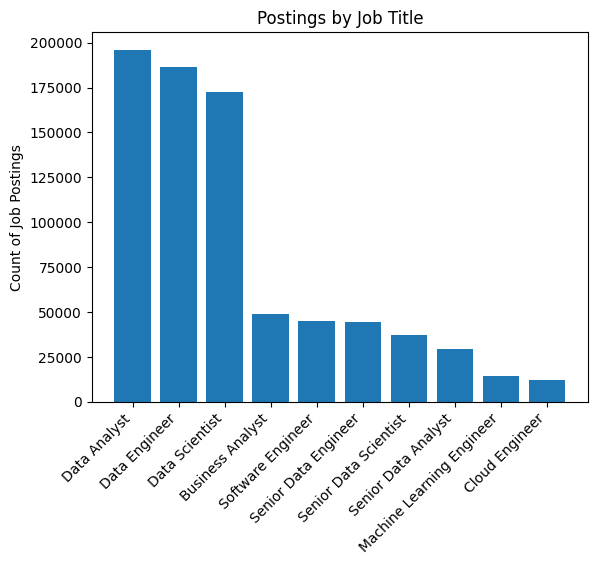

In [ ]:
# To clean up the above graph and make it presentable, we follow the following steps

# Adding a label
# ha -> horizontal alignment

plt.bar(job_counts.index, job_counts)
plt.title('Postings by Job Title')
plt.ylabel('Count of Job Postings')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

## Plotting using Pandas

<Axes: xlabel='job_title_short'>

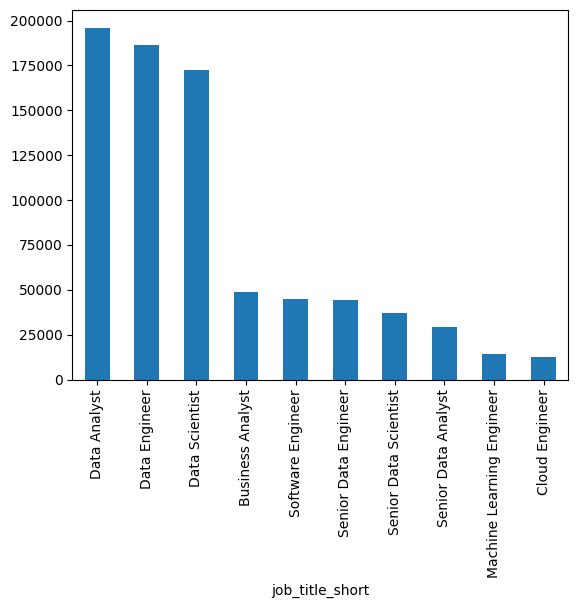

In [ ]:
# job_counts is a series here

job_counts.plot(kind = 'bar')

<Axes: xlabel='job_title_short', ylabel='count'>

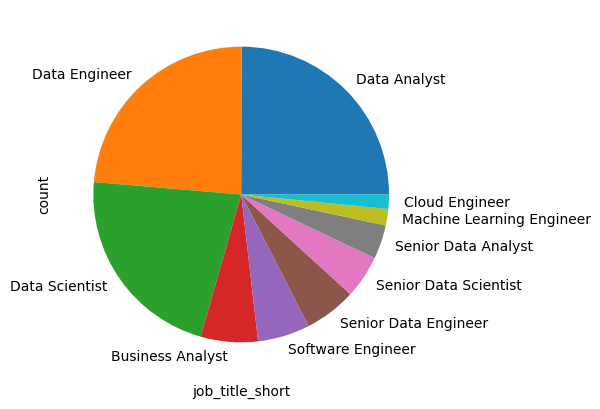

In [ ]:
job_counts.plot(kind = 'line')
job_counts.plot(kind = 'pie')

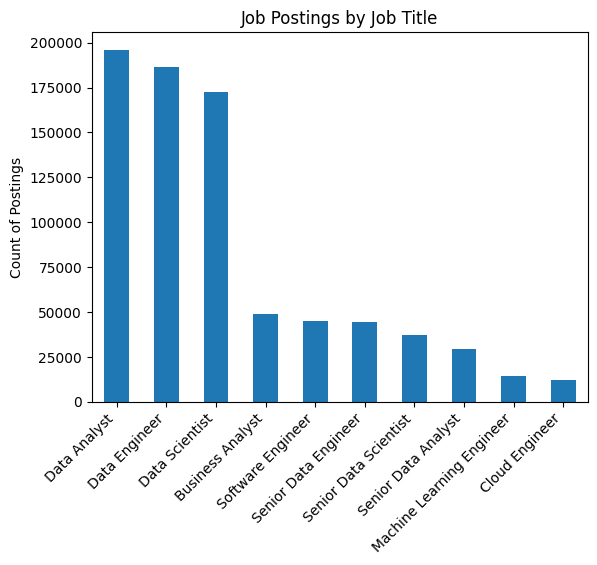

In [ ]:
job_counts.plot(kind = 'bar')
plt.title('Job Postings by Job Title')
plt.ylabel('Count of Postings')
plt.xlabel('')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

In [ ]:
# Performing the above operatoins on a dataframe instead
# It is important to provide the 'x' and the 'y' parameters since a dataframe has multiple different columns and needs to know what is to be plotted

# To show overtime how the salary is trending over the year in 2023

df[['job_posted_date', 'salary_year_avg']].dropna(subset = ['salary_year_avg'])

df.plot(x = 'job_posted_date', y = 'salary_year_avg', kind = 'line')

## Median Salary vs Data Science Jobs

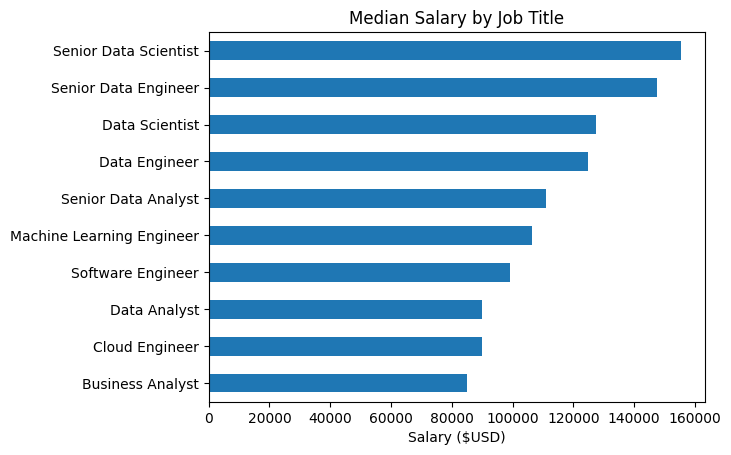

In [ ]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()
job_salary.plot(kind = 'barh')
plt.xlabel('Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()